# Mapping with Satellite imagery

## Using Satellite Imagery for Mapping in R

### **Introduction**

We have learnt to map using `{sf}`, `{terra}` and `{tidytera}` packages. Now we will move on to some advanced mapping. Remote sensing is where satellites circling the globe take measurements of reflected radiation while looking at the earth. This imagery could cover visible ranges, non-visible ranges, combinations of these, and many other options. The advantage of having remote sensing is that it can cover huge areas in a short amount of time, with varyong levels of spatial resolution. satellite sensors will also have varying levels of what we call spactral resolutions.

### **Spectral Resolutions**

Spectral resolution refers to the ability of a sensor or spectrometer to distinguish between different wavelengths of light within an electromagnetic spectrum. The electomagnetic spectrum ranges from wavelengths of 1000s (radio) to 10 metres (gamma radiation). Visible light ranges from around 380 nm to 700 nm (3.8x10 to 7x10 metres). Human eyes can see four bands of visible light at different wavelengths (419, 496, 531 and 559 nm). Depending on the satellite sensor being used they can measure reflectance of a much wider range of radiation and therefore provide important information about the surface of the planet or its atmosphere. Each sensor (like the cones or rods in our eyes) is often called a band and, depending on how many sensors there are and how much of the EM spectrum they measure, will have a certain spectral resolution. The range of satellites and their applications is massive such as, crop monitoring, sea ice mapping, surface temperature measurement, atmospheric properties and geological information. In this section We will focus on multispectral (from around 10 bands) satellite imagery that is easily accessible, free-to-use and has moderate to high spatial resolution (10 - 30 m).

### Data used

We will access some Landsat data from this USGS EarthExplorer. You can download data from here: https://earthexplorer.usgs.gov


After downloading, there are 10 bands of Landsat. Lets bring them into R using `{terra}`, inspect and plot them with `{tidyterra}` as we have previously plotted other `.tif` files. We can bring in each file separately, or we can use common naming patterns. We see that `{tidyterra}` resamples the rasters to a lower resolution to plot, we can set this value to be higher if we want higher resolution plots with `maxcell =` and some value greater than **5000000**. We will leave it as it is for now to make things quicker.

_Since we will not be using all the `.tif` files, I would suggest deleting all other files except those labelled with B1 - B7. That way you do not waste storage space._

In [1]:
options(
  repr.plot.width  = 9,
  repr.plot.height = 6,
  repr.plot.res    = 200
)

# These options center our plots and gives them a better resolution than default.

In [3]:
library(tidyverse)
library(terra)
library(tidyterra)

In [4]:
# Blue
b2 <- rast('Data/Cape_Landsat/LC08_L2SP_175084_20260120_20260129_02_T1_SR_B2.tif')
# Green
b3 <- rast('Data/Cape_Landsat/LC08_L2SP_175084_20260120_20260129_02_T1_SR_B3.tif')
# Red
b4 <- rast('Data/Cape_Landsat/LC08_L2SP_175084_20260120_20260129_02_T1_SR_B4.tif')
# Near Infrared (NIR)
b5 <- rast('Data/Cape_Landsat/LC08_L2SP_175084_20260120_20260129_02_T1_SR_B5.tif')

crs(b2, describe = TRUE)

name,authority,code,area,extent
<chr>,<chr>,<chr>,<chr>,<list>
WGS 84 / UTM zone 34N,EPSG,32634,"Between 18°E and 24°E, northern hemisphere between equator and 84°N, onshore and offshore. Albania. Belarus. Bosnia and Herzegovina. Bulgaria. Central African Republic. Chad. Croatia. Democratic Republic of the Congo (Zaire). Estonia. Finland. Greece. Hungary. Italy. Kosovo. Latvia. Libya. Lithuania. Montenegro. North Macedonia. Norway, including Svalbard and Bjornoys. Poland. Romania. Russian Federation. Serbia. Slovakia. Sudan. Sweden. Ukraine","18, 24, 0, 84"


In [5]:
res(b2)

[1] 30 30

In [6]:
ext(b2)

SpatExtent : 156885, 386115, -3948315, -3717285 (xmin, xmax, ymin, ymax)

<SpatRaster> resampled to 500550 cells.


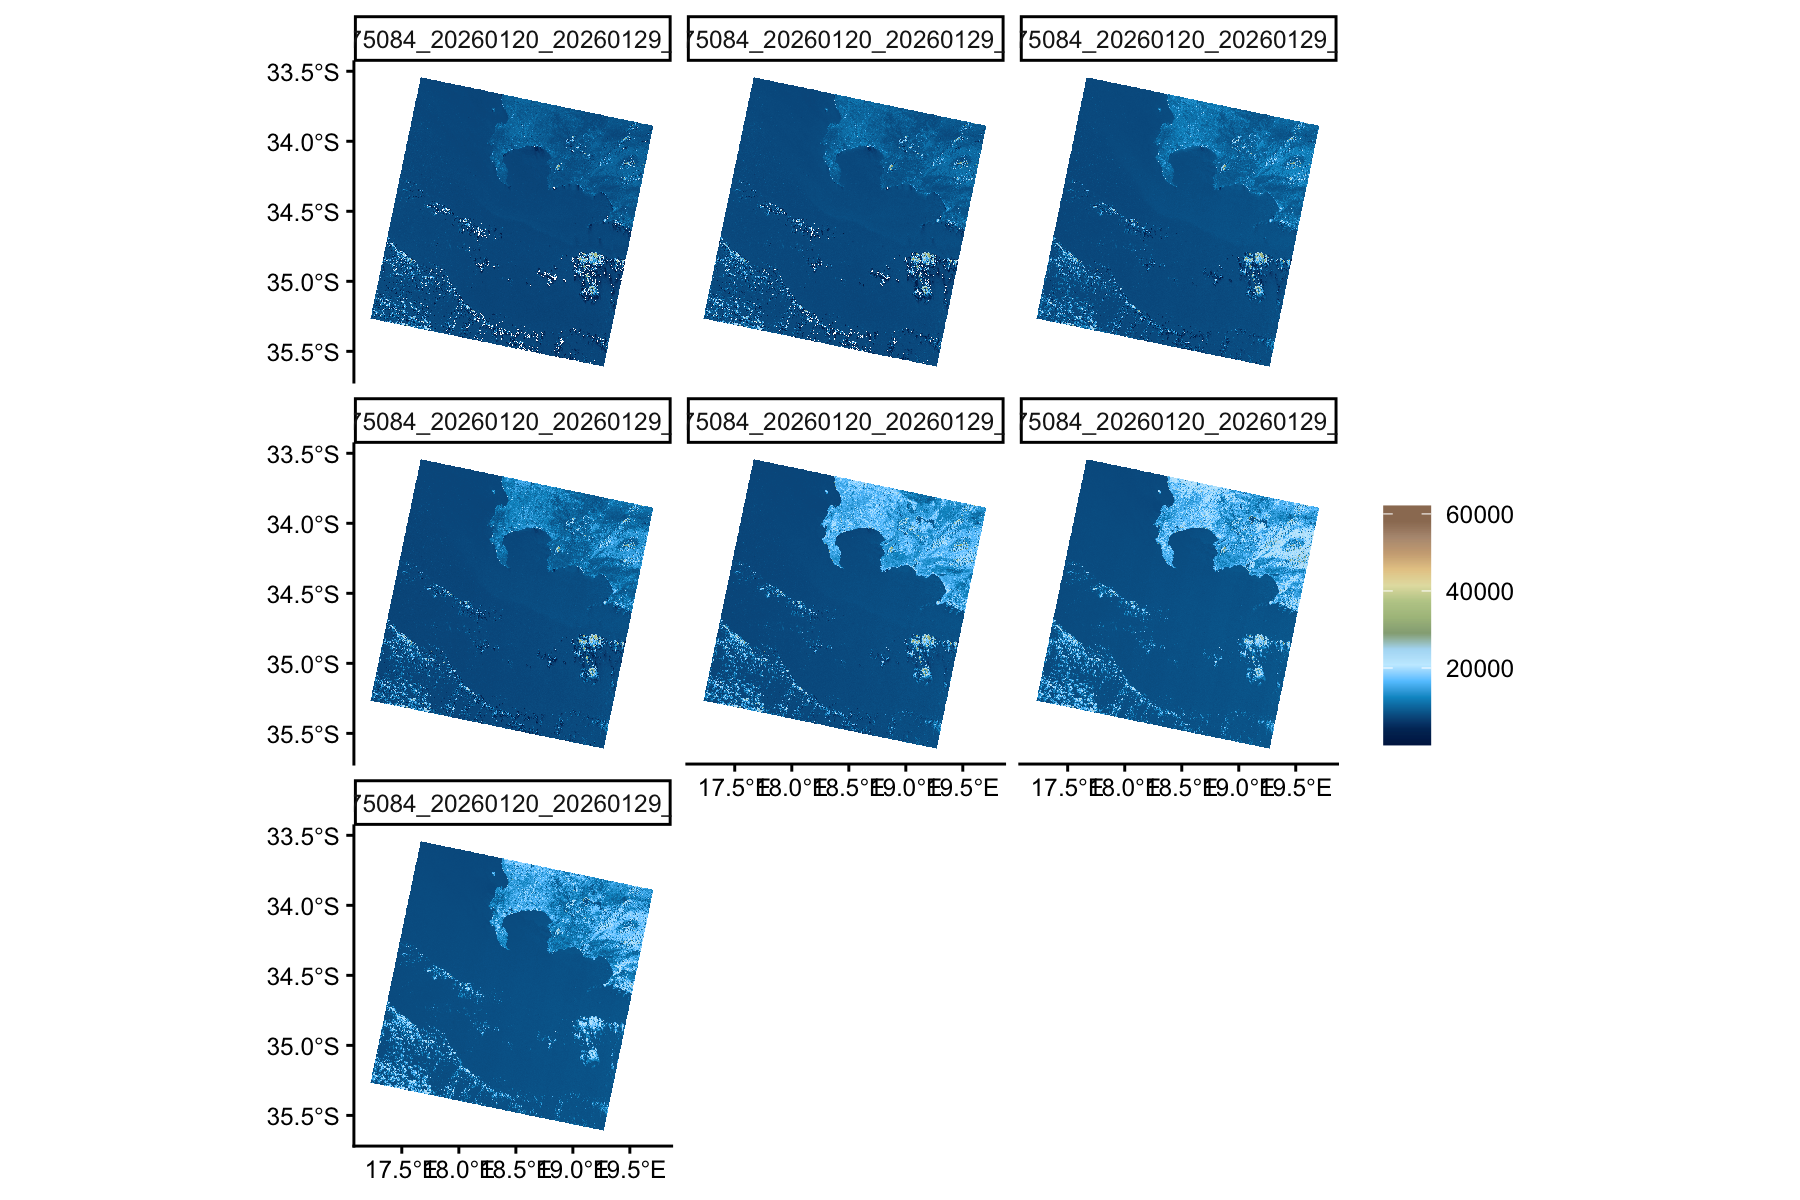

In [7]:
filenames <- list.files('Data/Cape_Landsat/', pattern = "*.tif", full.names  = TRUE, ignore.case = TRUE)

Combined_Landsat <- rast(filenames)

ggplot()+
  geom_spatraster(data = Combined_Landsat)+
  labs(fill = "")+
  facet_wrap(~lyr)+
  scale_fill_hypso_c("colombia", na.value = NA)+
  theme_classic()

### RGB Plotting

We can merge the bands together to make an RGB composite image. These will take different bands for true Red, Green and Blue imagery, or we can also do a false colour image using the Near Infrared band. To do this, we set the maximum value. The default maximum value is 255, but our data only ranges from 0 to around 40000, but even so even then the majority is below 30000, so we will set it to 40000 as the maximum colour.

<SpatRaster> resampled to 500550 cells.
<SpatRaster> resampled to 500550 cells.


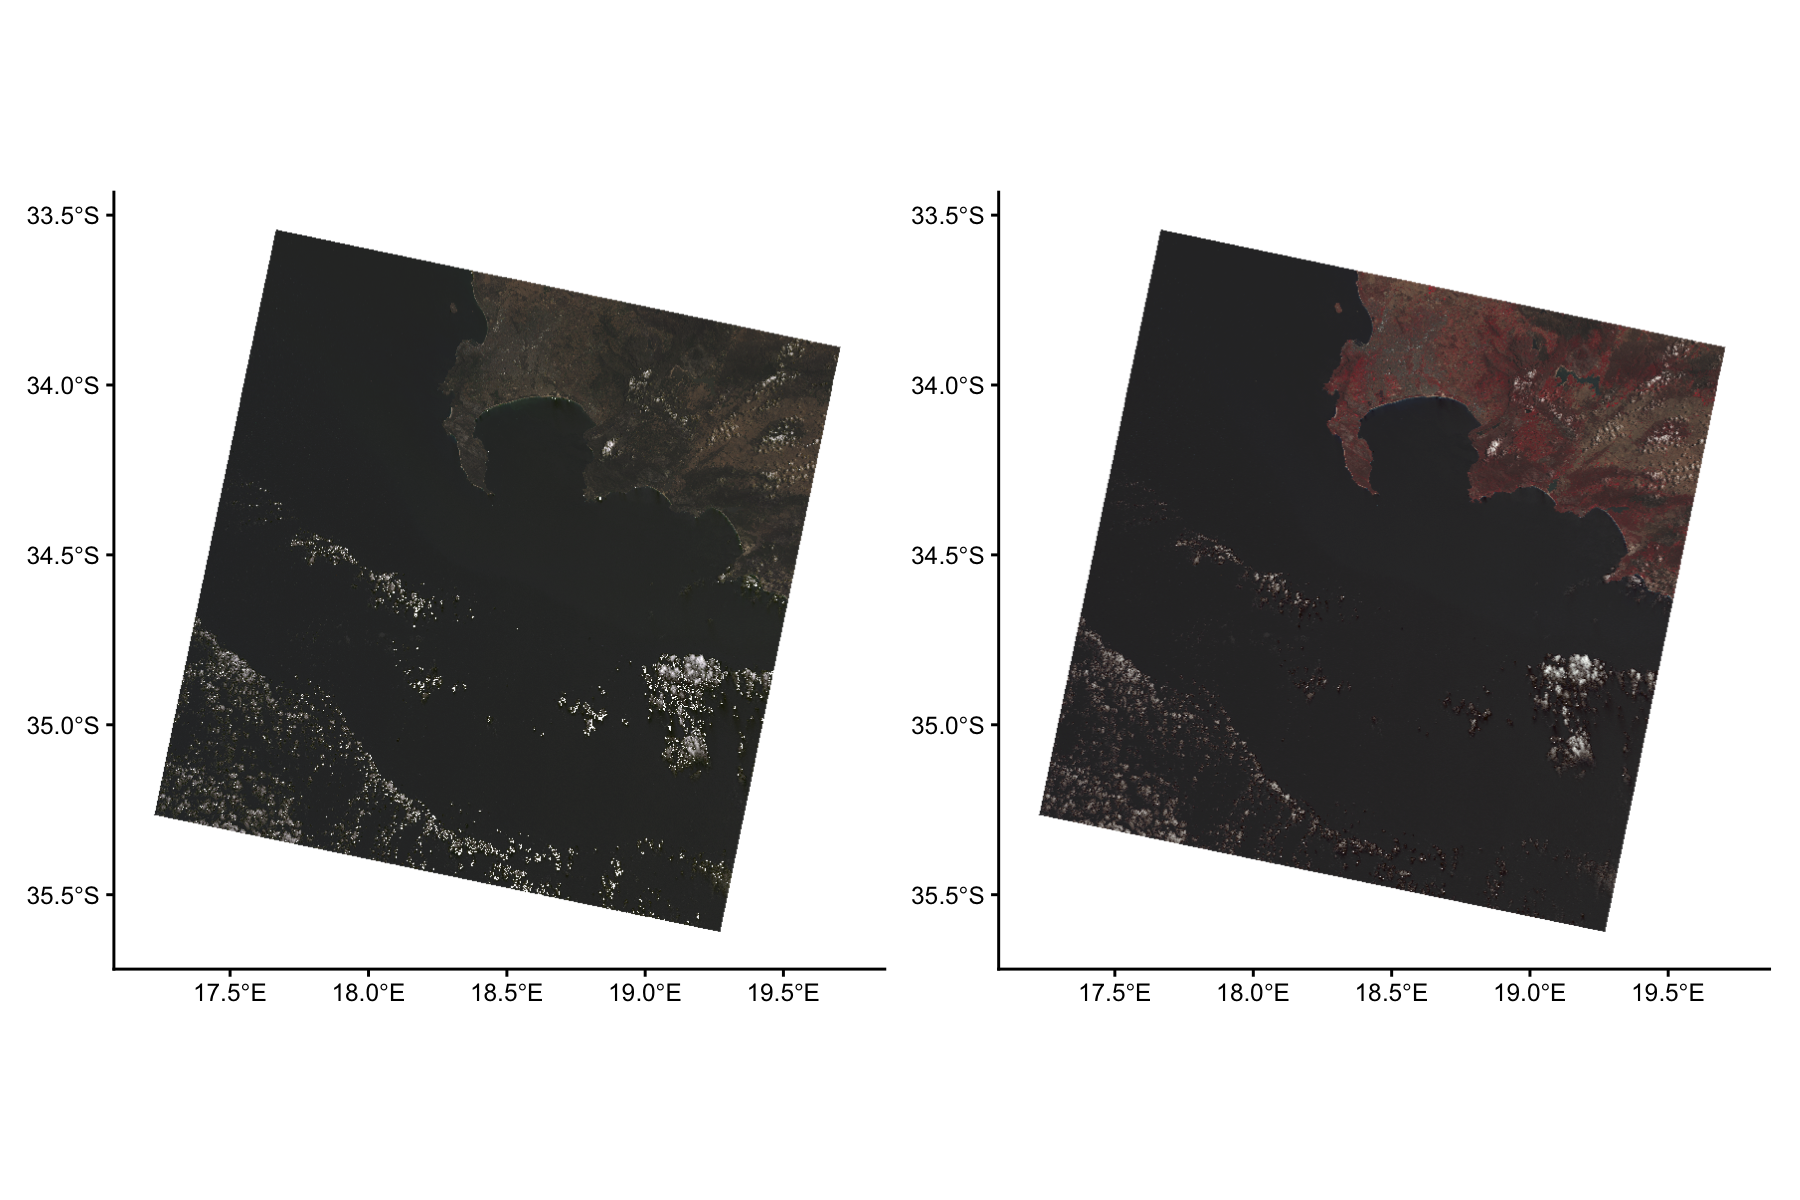

In [9]:
library(patchwork)

p1 <- ggplot()+
  geom_spatraster_rgb(data = Combined_Landsat,
                      r = 4,
                      g = 3,
                      b = 2,
                      max_col_value = 40000,
                      interpolate = TRUE)+
  theme_classic()


p2 <- ggplot()+
  geom_spatraster_rgb(data = Combined_Landsat,
                      r = 5,
                      g = 4,
                      b = 3,
                      max_col_value = 40000,
                      interpolate = TRUE)+
  theme_classic()

p1 + p2

The images still show the ocean surface and not just the land. TTo get a better image of Cape Town, we can create a polygon of South Africa and clip the landsat images to that polygon so that we get an image of only Cape Town without the ocean. This will make it easier to visualise land-based data in the up next.

In [13]:
library(rnaturalearth)
library(sf)

Linking to GEOS 3.14.1, GDAL 3.12.0, PROJ 9.7.0; sf_use_s2() is TRUE



In [14]:
# Get South Africa boundary
sa_boundary <- ne_countries(country = "South Africa", scale = "large", returnclass = "sf")

In [15]:
# Check actual CRS of the raster
crs(Combined_Landsat)

# Reproject SA boundary to match raster CRS
sa_boundary_proj <- st_transform(sa_boundary, crs(Combined_Landsat))

[1] "PROJCRS[\"WGS 84 / UTM zone 34N\",\n    BASEGEOGCRS[\"WGS 84\",\n        DATUM[\"World Geodetic System 1984\",\n            ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n                LENGTHUNIT[\"metre\",1]]],\n        PRIMEM[\"Greenwich\",0,\n            ANGLEUNIT[\"degree\",0.0174532925199433]],\n        ID[\"EPSG\",4326]],\n    CONVERSION[\"UTM zone 34N\",\n        METHOD[\"Transverse Mercator\",\n            ID[\"EPSG\",9807]],\n        PARAMETER[\"Latitude of natural origin\",0,\n            ANGLEUNIT[\"degree\",0.0174532925199433],\n            ID[\"EPSG\",8801]],\n        PARAMETER[\"Longitude of natural origin\",21,\n            ANGLEUNIT[\"degree\",0.0174532925199433],\n            ID[\"EPSG\",8802]],\n        PARAMETER[\"Scale factor at natural origin\",0.9996,\n            SCALEUNIT[\"unity\",1],\n            ID[\"EPSG\",8805]],\n        PARAMETER[\"False easting\",500000,\n            LENGTHUNIT[\"metre\",1],\n            ID[\"EPSG\",8806]],\n        PARAMETER[\"False northing\",0,\n            LENGTHUNIT[\"metre\",1],\n            ID[\"EPSG\",8807]]],\n    CS[Cartesian,2],\n        AXIS[\"(E)\",east,\n            ORDER[1],\n            LENGTHUNIT[\"metre\",1]],\n        AXIS[\"(N)\",north,\n            ORDER[2],\n            LENGTHUNIT[\"metre\",1]],\n    USAGE[\n        SCOPE[\"Navigation and medium accuracy spatial referencing.\"],\n        AREA[\"Between 18°E and 24°E, northern hemisphere between equator and 84°N, onshore and offshore. Albania. Belarus. Bosnia and Herzegovina. Bulgaria. Central African Republic. Chad. Croatia. Democratic Republic of the Congo (Zaire). Estonia. Finland. Greece. Hungary. Italy. Kosovo. Latvia. Libya. Lithuania. Montenegro. North Macedonia. Norway, including Svalbard and Bjornoys. Poland. Romania. Russian Federation. Serbia. Slovakia. Sudan. Sweden. Ukraine.\"],\n        BBOX[0,18,84,24]],\n    ID[\"EPSG\",32634]]"

In [16]:
# Crop to the bounding box of the boundary first (faster)
landsat_cropped <- crop(Combined_Landsat, sa_boundary_proj)

# Mask to the actual land polygon (ocean becomes NA)
landsat_masked <- mask(landsat_cropped, sa_boundary_proj)

Now lets plot the RGB composite again

<SpatRaster> resampled to 500550 cells.
<SpatRaster> resampled to 500550 cells.


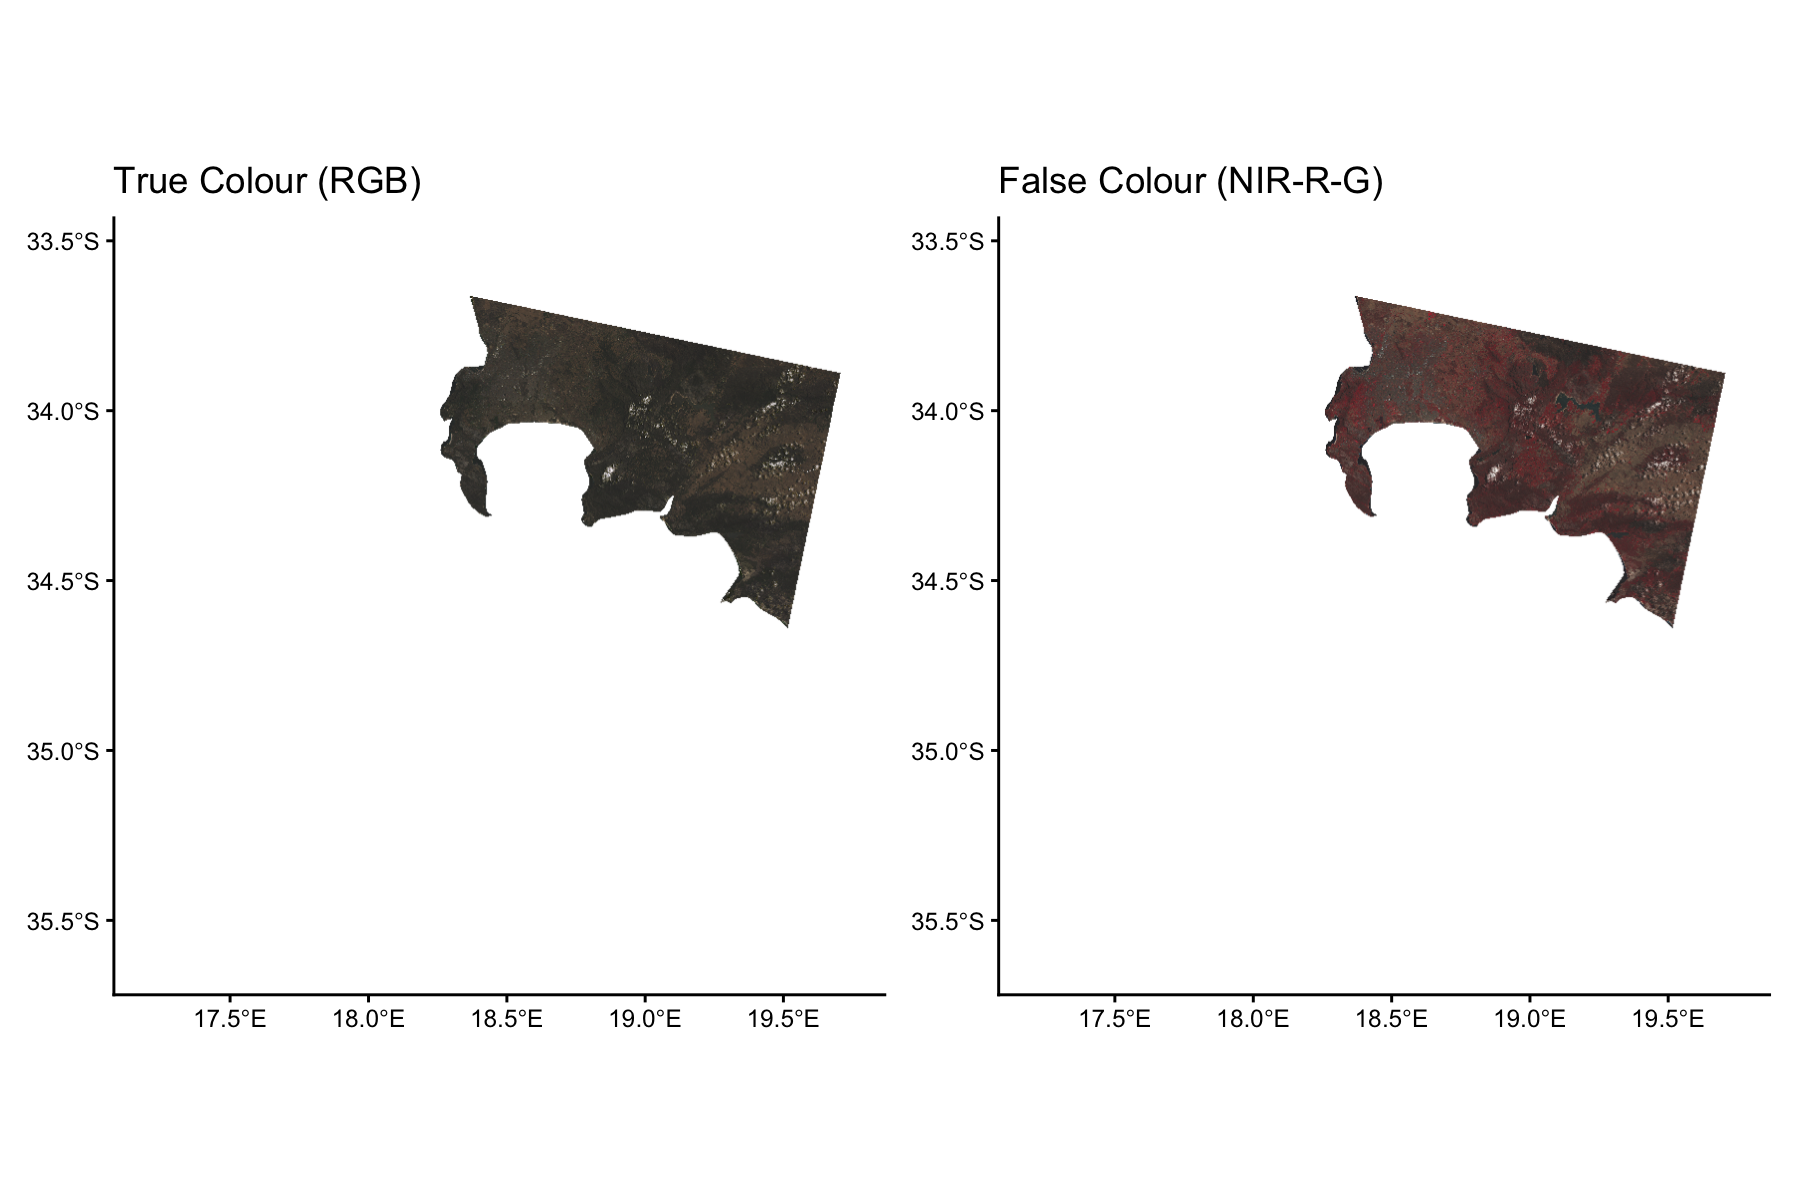

In [17]:
p1 <- ggplot() +
  geom_spatraster_rgb(data = landsat_masked,
                      r = 4, g = 3, b = 2,
                      max_col_value = 40000,
                      interpolate = TRUE) +
  labs(title = "True Colour (RGB)") +
  theme_classic()

p2 <- ggplot() +
  geom_spatraster_rgb(data = landsat_masked,
                      r = 5, g = 4, b = 3,
                      max_col_value = 40000,
                      interpolate = TRUE) +
  labs(title = "False Colour (NIR-R-G)") +
  theme_classic()

p1 + p2

So far so good, I think we can improve it by zooming in a bit into the land mass

In [18]:
# Define a Cape Town AOI (in WGS84, then reproject)
cape_town_bbox <- st_bbox(c(xmin = 18.2, xmax = 19.0, 
                             ymin = -34.5, ymax = -33.7),
                           crs = st_crs(4326))

cape_town_poly <- st_as_sfc(cape_town_bbox) |> st_sf()
cape_town_proj <- st_transform(cape_town_poly, crs(Combined_Landsat))

# Crop to AOI
landsat_ct <- crop(Combined_Landsat, cape_town_proj)
# Mask to land
landsat_ct_masked <- mask(landsat_ct, sa_boundary_proj)

<SpatRaster> resampled to 500256 cells.
<SpatRaster> resampled to 500256 cells.


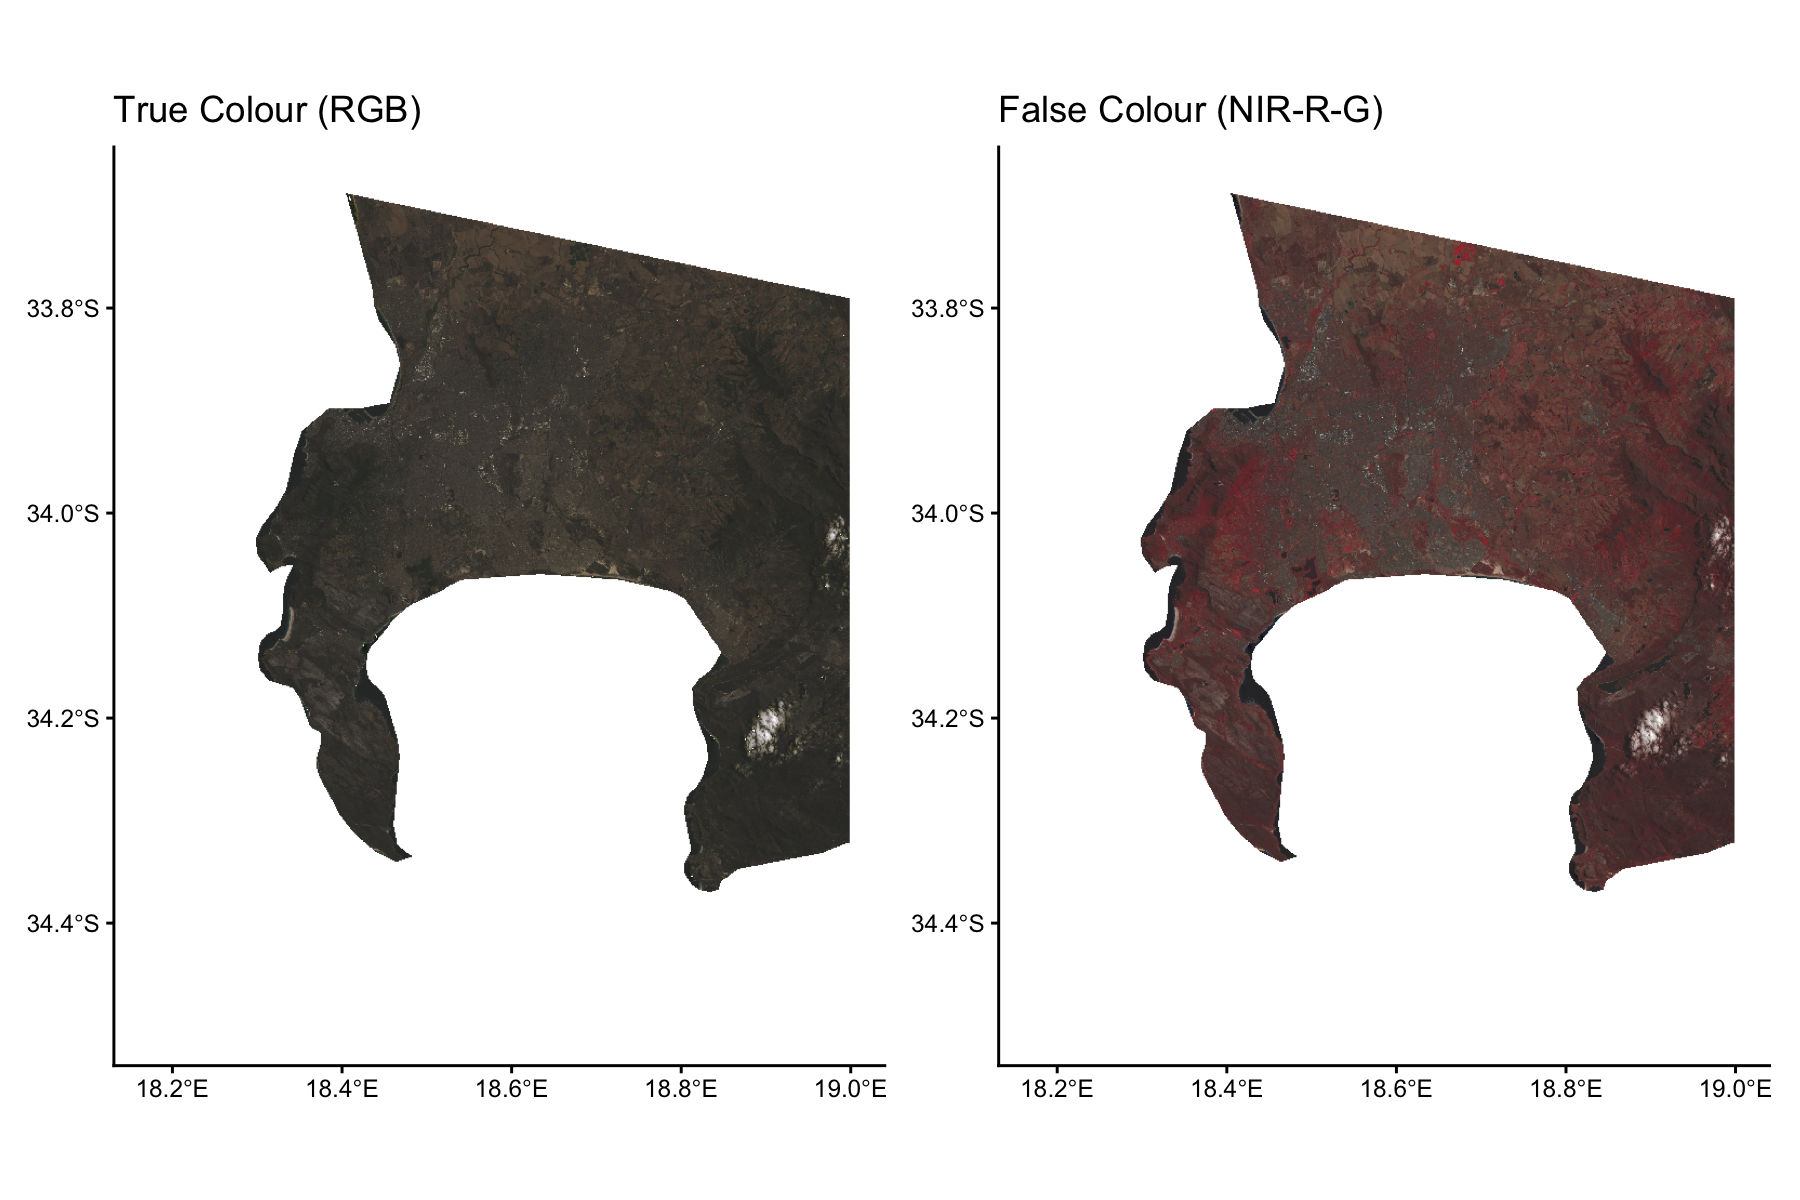

In [19]:
p1 <- ggplot() +
  geom_spatraster_rgb(data = landsat_ct_masked,
                      r = 4, g = 3, b = 2,
                      max_col_value = 40000,
                      interpolate = TRUE) +
  labs(title = "True Colour (RGB)") +
  theme_classic()

p2 <- ggplot() +
  geom_spatraster_rgb(data = landsat_ct_masked,
                      r = 5, g = 4, b = 3,
                      max_col_value = 40000,
                      interpolate = TRUE) +
  labs(title = "False Colour (NIR-R-G)") +
  theme_classic()

p1 + p2

### Calculating Index from Reflectance

In order to estimate different elements of growth in terrestrial and intertidal plants, many remote sensing practitioners use indices or band ratios. One very common one is the Normalised Difference Vegetation Index (NDVI). This is the normalised difference between the red (R) and infrared (NIR) bands of a satellite. We can easily calculate the NDVI for our whole image and then plot it. The equation for NDVI is:

$$NDVI = \frac{NIR - Red}{NIR + Red}$$

<SpatRaster> resampled to 500256 cells.


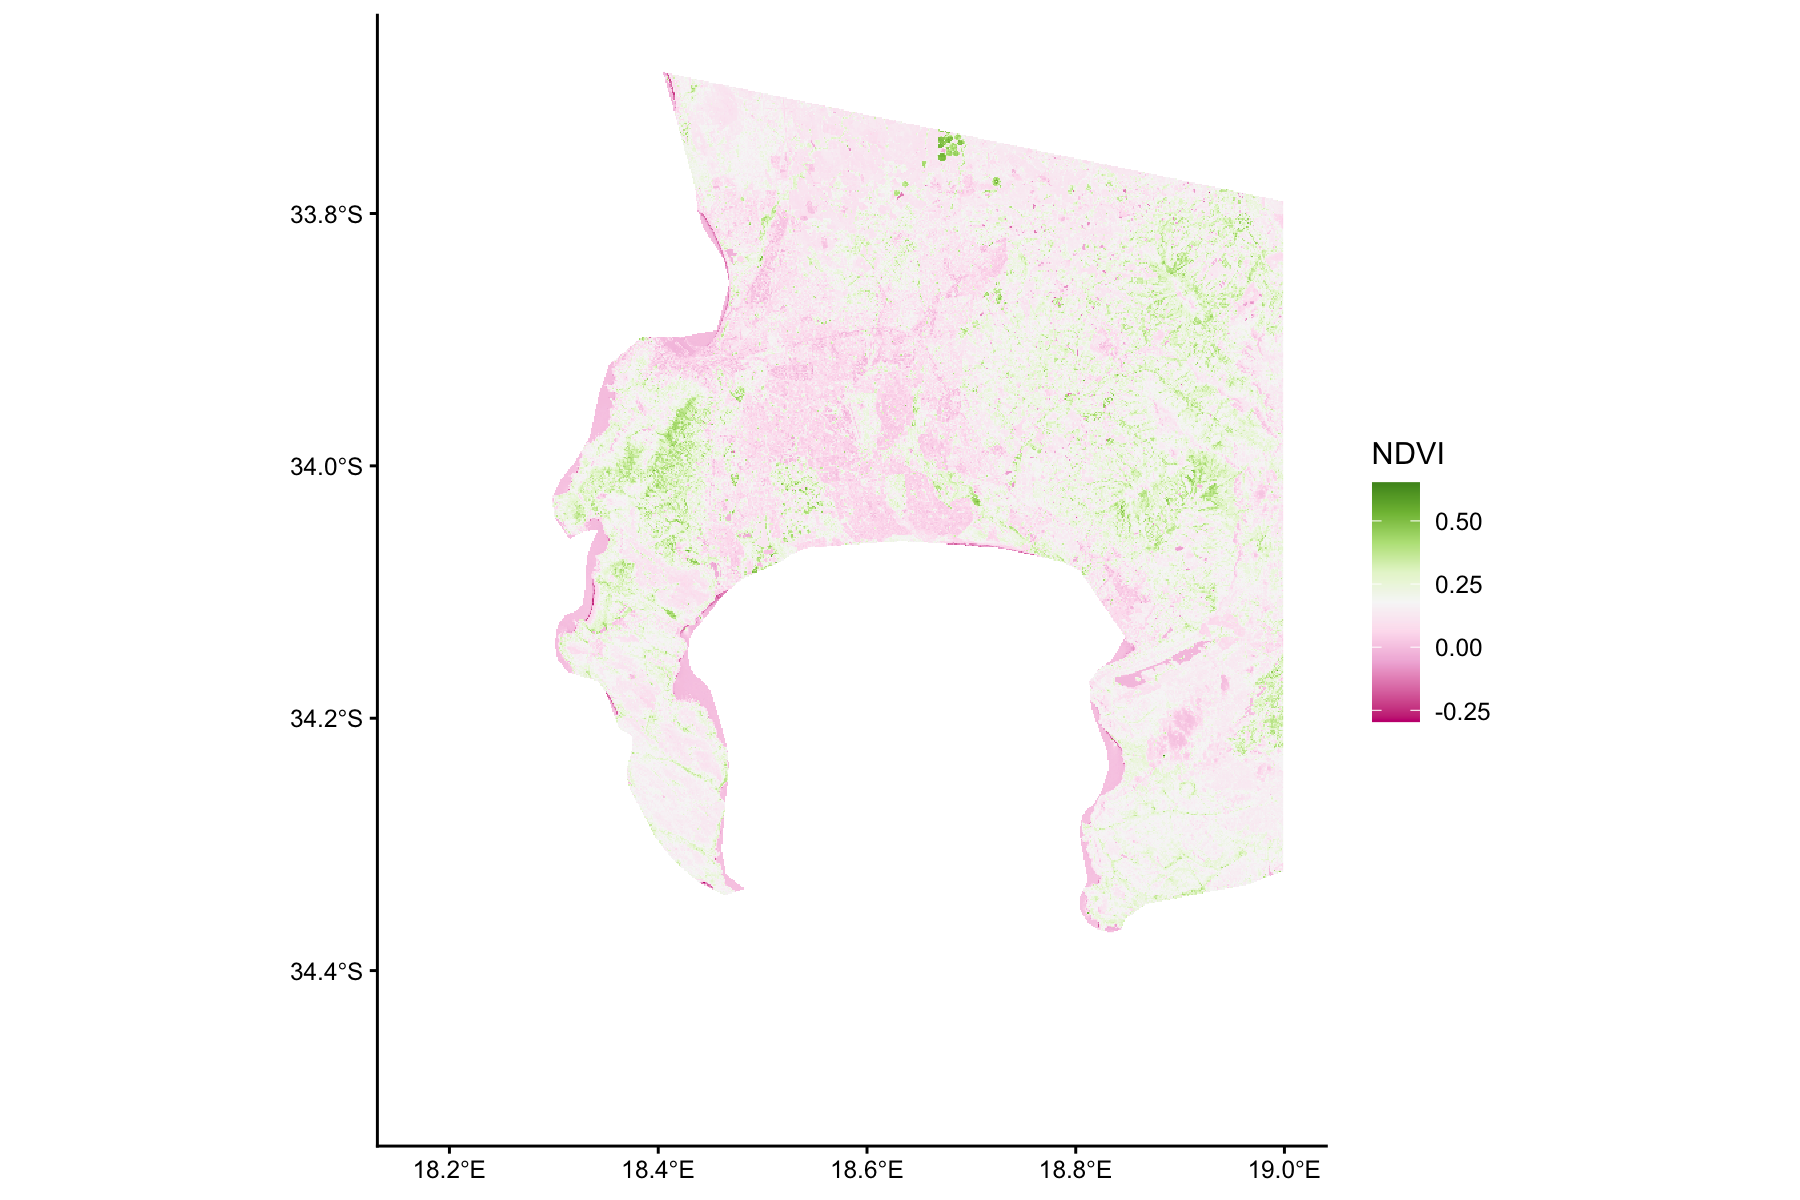

In [24]:
NDVI <- (landsat_ct_masked[[5]] - landsat_ct_masked[[4]])/(landsat_ct_masked[[5]] + landsat_ct_masked[[4]])

ggplot()+
  geom_spatraster(data = NDVI)+
  labs(fill = "NDVI")+
  scale_fill_whitebox_c("pi_y_g", na.value = NA)+
  theme_classic()